In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go
import time
from datetime import timedelta
import json
import os
import psutil
import gc
import math


gc.collect()  
device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
############ customization
length = 48
width = 48
n1 = 13
n2 = 13
judge = 0

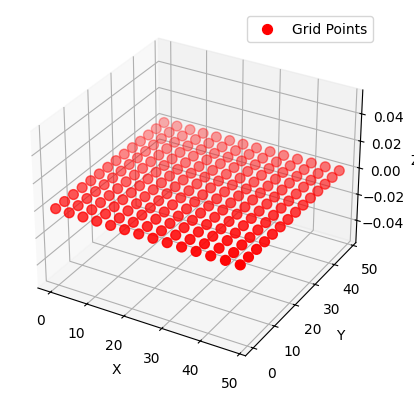

In [3]:
############### Problem context formulation

def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=0, z=0, height=0):
    x_points = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for x in x_points:
        for y in y_points:
            if y == width / 2:
                grid_points.append([x, y, height])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

def generate_connectivity_matrix(new_coords):
    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}
    connectivity = []

    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:
        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 

        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  

        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points = generate_rectangular_grid_sg(length, width, n1, n2, judge)
connectivity = generate_connectivity_matrix(grid_points)
plot_grid(grid_points, length, width)


###########################################################################################################################################################
n_dof_per_node = 6  # Degrees of freedom per node
grid_points = torch.tensor(grid_points, device=device, dtype=torch.float32)
total_dof = n_dof_per_node * len(grid_points)

########## Surrounding fixed
x_max = grid_points[:, 0].max()
x_min = grid_points[:, 0].min()
y_max = grid_points[:, 1].max()
y_min = grid_points[:, 1].min()

Fixed_nodes = torch.where(
    #     (grid_points[:, 0] == x_max) | 
    # (grid_points[:, 0] == x_min) |    
    (grid_points[:, 1] == y_max) |  # y = y_max
    (grid_points[:, 1] == y_min)    # y = y_min
)[0]

Fixed_nodes += 1
Free_nodes = []

n_elements = len(connectivity)
n_nodes = len(grid_points)

for i in range(1, n_nodes + 1):
    if i not in Fixed_nodes:
        Free_nodes.append(i)


####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])

##########################################################################################################################################################
##########################################################################################################################################################

In [4]:
rows = n2 + 1
cols = n1 + 1

idx_matrix = [[0 for _ in range(cols)] for _ in range(rows)]

for k in range(rows * cols):
    row = k % rows
    col = k // rows
    idx_matrix[row][col] = k
V_matrix = torch.arange(0, n2 * (n1 + 1)).reshape(n1 + 1, n2).T

start = n2 * (n1 + 1)
H_matrix = torch.arange(start, start + (n2 + 1) * n1)
H_matrix = H_matrix.reshape(n1 + 1 , n2)
H_matrix = H_matrix.flip(0)
print(V_matrix)
print(H_matrix)

tensor([[  0,  13,  26,  39,  52,  65,  78,  91, 104, 117, 130, 143, 156, 169],
        [  1,  14,  27,  40,  53,  66,  79,  92, 105, 118, 131, 144, 157, 170],
        [  2,  15,  28,  41,  54,  67,  80,  93, 106, 119, 132, 145, 158, 171],
        [  3,  16,  29,  42,  55,  68,  81,  94, 107, 120, 133, 146, 159, 172],
        [  4,  17,  30,  43,  56,  69,  82,  95, 108, 121, 134, 147, 160, 173],
        [  5,  18,  31,  44,  57,  70,  83,  96, 109, 122, 135, 148, 161, 174],
        [  6,  19,  32,  45,  58,  71,  84,  97, 110, 123, 136, 149, 162, 175],
        [  7,  20,  33,  46,  59,  72,  85,  98, 111, 124, 137, 150, 163, 176],
        [  8,  21,  34,  47,  60,  73,  86,  99, 112, 125, 138, 151, 164, 177],
        [  9,  22,  35,  48,  61,  74,  87, 100, 113, 126, 139, 152, 165, 178],
        [ 10,  23,  36,  49,  62,  75,  88, 101, 114, 127, 140, 153, 166, 179],
        [ 11,  24,  37,  50,  63,  76,  89, 102, 115, 128, 141, 154, 167, 180],
        [ 12,  25,  38,  51,  64,  77,  

In [5]:
def Symmetry_shaper(q, matrix):

    rows, cols = matrix.shape

    row_odd = rows % 2 == 1
    col_odd = cols % 2 == 1
    
    if row_odd:

        q = torch.cat([q, q.flip(0)[1:,:]], dim=0)
    else:

        q = torch.cat([q, q.flip(0)], dim=0)
    

    if col_odd:

        q = torch.cat([q, q.flip(1)[:,1:]], dim=1)
    else:

        q = torch.cat([q, q.flip(1)], dim=1)
    
    return q
    

In [6]:
############################################################# Force condition
def Force_mat(F_value, F_type, total_dof=total_dof, Free_nodes=Free_nodes, judge=0):
    
    F = torch.zeros(total_dof, dtype=torch.float32, device=device)
    
    if judge == 0:
        F_value = torch.tensor([F_value] * len(Free_nodes), device=device) * 1000 # The force value/direction
        F_type = [F_type] * len(Free_nodes)  # The force type
    else:
        F_value = torch.tensor(F_value) * 1000
        F_value = torch.tensor(F_type)
    
    for idx, i in enumerate(Free_nodes):
        F[6 * (i - 1) + F_type[idx]] = F_value[idx]  # unit: KN / KN*m
        
    return F, F_value

In [7]:
def save_fdm(state_idx, grid_points, new_node_coords, 
            connectivity, Free_nodes, Fixed_nodes, force, SED,
            save_dir="results", max_states=6):
    """
    多状态组合图保存函数
    
    参数:
        state_idx: 状态序号 (0=初始, 1=第cut次, 2=第2*cut次...)
        max_states: 组合图中最多显示的状态数
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 数据准备
    x_orig = grid_points[:, 0].cpu().detach().numpy()
    y_orig = grid_points[:, 1].cpu().detach().numpy()
    z_orig = grid_points[:, 2].cpu().detach().numpy()
    
    x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
    y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
    z_fdm = new_node_coords[:, 2].cpu().detach().numpy()
    
    # 计算当前高度
    current_height = max(z_fdm)
    
    # 初始化图形容器
    if not hasattr(save_fdm, 'fig'):
        save_fdm.fig = plt.figure(figsize=(24, 16))
        save_fdm.axes = [save_fdm.fig.add_subplot(2, 3, i+1, projection='3d') 
                       for i in range(max_states)]
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
        save_fdm.saved_states = 0
        save_fdm.max_z = 0  # 用于统一z轴尺度
    
    # 检查是否已存满
    if save_fdm.saved_states >= max_states:
        filename = os.path.join(save_dir, f"FDM_States_{max_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        delattr(save_fdm, 'fig')
        delattr(save_fdm, 'axes')
        delattr(save_fdm, 'saved_states')
        delattr(save_fdm, 'max_z')
        print(f"Saved full states to {filename}")
        return
    
    # 更新最大z值（用于统一坐标尺度）
    if current_height > save_fdm.max_z:
        save_fdm.max_z = current_height
    
    # 获取当前子图并清除旧内容
    ax = save_fdm.axes[save_fdm.saved_states]
    ax.clear()
    
    # ========== 可视化绘制 ==========
    # 1. 绘制原始网格（浅灰色虚线）
    for i, j in connectivity:
        ax.plot([x_orig[i-1], x_orig[j-1]],
                [y_orig[i-1], y_orig[j-1]],
                [z_orig[i-1], z_orig[j-1]], 
                ':', color='#CCCCCC', linewidth=0.8, alpha=0.7)
    
    # 2. 绘制当前状态网格
    color = '#1f77b4' if state_idx == 0 else '#ff7f0e'  # 初始蓝色，迭代橙色
    for i, j in connectivity:
        ax.plot([x_fdm[i-1], x_fdm[j-1]],
                [y_fdm[i-1], y_fdm[j-1]],
                [z_fdm[i-1], z_fdm[j-1]], 
                '-', color=color, linewidth=1.8, alpha=0.9)
    
    # 3. 标记固定节点（黑色实心圆）
    for node in Fixed_nodes:
        ax.scatter(x_fdm[node-1], y_fdm[node-1], z_fdm[node-1],
                  c='black', s=50, marker='o', alpha=0.8)
    
    # 4. 添加高度标注（替换原来的力值标注）
    ax.text(x=0.05, y=0.90, z=save_fdm.max_z*1.05,
           s=f"Height: {current_height:.2f}m\nSE: {SED:.8f} ", 
           transform=ax.transAxes, 
           fontsize=10,
           bbox=dict(facecolor='white', alpha=0.7))
    
    # ========== 子图装饰 ==========
    ax.set_xlabel('X (m)', fontsize=9)
    ax.set_ylabel('Y (m)', fontsize=9)
    ax.set_zlabel('Z (m)', fontsize=9)
    ax.set_title(f"State {state_idx}" if state_idx > 0 else "Initial State", 
                fontsize=11, pad=12)
    ax.set_zlim(0, save_fdm.max_z * 1.1)  # 统一z轴尺度
    ax.view_init(elev=35, azim=45)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # 更新状态计数器
    save_fdm.saved_states += 1
    
    # 如果是最后一个状态，立即保存
    if save_fdm.saved_states == max_states:
        filename = os.path.join(save_dir, f"FDM_States_{max_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        delattr(save_fdm, 'fig')
        delattr(save_fdm, 'axes')
        delattr(save_fdm, 'saved_states')
        delattr(save_fdm, 'max_z')
        print(f"Saved full states to {filename}")


def finalize_fdm(save_dir="results", completed=False):
    """
    最终化处理函数
    
    参数:
        save_dir: 保存目录
        completed: 是否完成所有迭代 (True=已完成全部迭代，False=提前终止)
    """
    if not hasattr(save_fdm, 'fig') or save_fdm.saved_states == 0:
        return
    
    # 如果已完成所有迭代，保存当前进度（不强制填满）
    if completed:
        filename = os.path.join(save_dir, 
                              f"FDM_States_completed_{save_fdm.saved_states}.png")
    # 如果是提前终止，保存上一次有效迭代
    else:
        # 回退一个状态，因为最后一次迭代可能不完整
        save_fdm.saved_states = max(0, save_fdm.saved_states - 1)
        filename = os.path.join(save_dir,
                              f"FDM_States_partial_{save_fdm.saved_states+1}.png")
    
    # 保存图像
    save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
    plt.close(save_fdm.fig)
    
    # 打印保存信息
    if completed:
        print(f"Saved completed states ({save_fdm.saved_states}/{len(save_fdm.axes)}) to {filename}")
    else:
        print(f"Saved last valid state ({save_fdm.saved_states+1}) to {filename}")
    
    # 清理属性
    for attr in ['fig', 'axes', 'saved_states', 'max_z']:
        if hasattr(save_fdm, attr):
            delattr(save_fdm, attr)


In [8]:
####### FDM part 
C = torch.zeros(n_elements, n_nodes, dtype=torch.float32, device=device)
for n, (i, j) in enumerate(connectivity):
    C[n, i - 1] = 1
    C[n, j - 1] = -1
    
px= torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)
py = torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)
pz = torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)


fixed_idces = torch.tensor([node - 1 for node in Fixed_nodes], device=device)
free_node_indices = torch.tensor([node - 1 for node in Free_nodes], device=device)

CF = C[:, fixed_idces]
CN = C[:, free_node_indices]

def FDM(Q, F_value, CN=CN, CF=CF, px=px, py=py, pz=pz, 
        fixed_idces=fixed_idces, free_node_indices=free_node_indices,
        node_coords=grid_points):
    
    pz[:, 0] = F_value
        
    Dn = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CN))
    DF = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CF))
    
    
    xF = node_coords[fixed_idces, 0].unsqueeze(1)
    yF = node_coords[fixed_idces, 1].unsqueeze(1)
    zF = node_coords[fixed_idces, 2].unsqueeze(1)
    
    xN = torch.matmul(torch.inverse(Dn), (px - torch.matmul(DF, xF)))
    yN = torch.matmul(torch.inverse(Dn), (py - torch.matmul(DF, yF)))
    zN = torch.matmul(torch.inverse(Dn), (pz - torch.matmul(DF, zF)))
        
    
    new_node_coords = node_coords.clone()
    new_node_coords[free_node_indices, 0] = xN.squeeze()
    new_node_coords[free_node_indices, 1] = yN.squeeze()
    new_node_coords[free_node_indices, 2] = zN.squeeze()
    
    return new_node_coords

In [9]:
###### FE part
D_radius = 0.75
D_young_modulus = 10e9 
D_shear_modulus = 0.7e9 
D_poisson_ratio = 0.3
cross_section_angle_a = 0  
cross_section_angle_b = 0  
a_small_number = 1e-10

def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    # Ensure theta is a tensor
    theta = torch.tensor(theta, dtype=torch.float32, device=device) if not isinstance(theta, torch.Tensor) else theta

    v_rotated = v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))
    return v_rotated

class Beam:
    def __init__(self, node_coordinates, R=D_radius, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates

        # Material and geometry
        self.radius = R
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio

        # Cross-sectional properties
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])  # Length of the beam
        self.Iy = (torch.pi * self.radius ** 4) / 4 
        self.Iz = self.Iy
        self.A = torch.pi * self.radius ** 2
        self.J = (torch.pi * self.radius ** 4) / 2

        # Stiffness components
        self.S_u = self.young_modulus * self.A / self.length
        self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        self.S_Tr = self.shear_modulus * self.J / self.length

        # Section rotations at the two ends
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        """Element stiffness matrix."""
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32, device=device)

        return K_element

    def System_Transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32, device=device)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T

    def nodal_transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        return lambda_matrix


def assemble_stiffness_matrix(beams, n_nodes, n_dof_per_node, connectivity):
    """Global stiffness matrix assembly."""
    total_dof = n_nodes * n_dof_per_node  # Total degrees of freedom
    K_global = torch.zeros((total_dof, total_dof), dtype=torch.float32, device=device)
    
    for idx, (i, j) in enumerate(connectivity):
        Matrix_T = beams[idx].System_Transform()  # Get transformation matrix
        K_element = torch.matmul(torch.transpose(Matrix_T, 0, 1),
                                 torch.matmul(beams[idx].get_element_stiffness_matrix(), Matrix_T))

        start_idx = (i - 1) * n_dof_per_node
        end_idx = (j - 1) * n_dof_per_node
        K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] += K_element[0:6, 0:6]
        K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] += K_element[6:12, 6:12]
        K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] += K_element[0:6, 6:12]
        K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] += K_element[6:12, 0:6]

    return K_global

def robust_solve(K_global, F, fixed_dof, max_attempts=3):
    
    attempts = 0
    while attempts < max_attempts:
        reg = 1e-6 * torch.eye(K_global.shape[0], device=K_global.device)
        reg[fixed_dof, fixed_dof] = 0  
        K_reg = K_global + reg
        try:
            cond_number = torch.linalg.cond(K_reg)
        except torch._C._LinAlgError:
            print("警告：条件数计算失败（矩阵可能奇异），自动设为0")
            cond_number = torch.tensor(0.0, device=K_reg.device)
        try:
            displacements = torch.linalg.solve(
                K_reg.to(torch.float64), 
                F.to(torch.float64)
            )
            sol_type = 0
            return displacements.to(K_global.dtype), sol_type, cond_number
            
        except RuntimeError:
            diag = torch.diag(K_global)
            extreme_mask = (diag > 1e12) & (~torch.isin(torch.arange(len(diag)), torch.tensor(fixed_dof)))  
            K_reg[extreme_mask] = 0
            K_reg[:, extreme_mask] = 0
            K_reg[extreme_mask, extreme_mask] = 1e12  
            
            K_reg[fixed_dof, :] = 0
            K_reg[:, fixed_dof] = 0
            K_reg[fixed_dof, fixed_dof] = 1e10  
            
            try:
                displacements, info = torch.linalg.cg(
                    K_reg.to(torch.float64),
                    F.to(torch.float64),
                    maxiter=5000,
                    atol=1e-6
                )
                if info > 0:
                    raise RuntimeError("CG nah nah")
                sol_type = 1
                return displacements.to(K_global.dtype), sol_type, cond_number
                
            except:
                K_pinv = torch.linalg.pinv(K_reg)
                K_pinv[fixed_dof, :] = 0  
                displacements = K_pinv @ F
                print("警告：使用伪逆求解，精度可能降低")
                sol_type = 2
                return displacements, sol_type, cond_number
                
        attempts += 1
    
    raise RuntimeError("无法求解线性系统")


def Strain_E(node_coords, connectivity, fixed_dof, F):
    # Element Assembly
    Beam_lens = []
    beams = []
    for connection in connectivity:
        node_1_coords = node_coords[connection[0] - 1]
        node_2_coords = node_coords[connection[1] - 1]
        beam = Beam(node_coordinates=torch.stack([node_1_coords, node_2_coords]),
                    R=D_radius, young_modulus=D_young_modulus,
                    shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                    Beta_b=cross_section_angle_b)
        beams.append(beam)
        Beam_lens.append(beam.length)
    
    # Stiffness renewal
    K_global = assemble_stiffness_matrix(beams, n_nodes=len(node_coords), n_dof_per_node=6, connectivity=connectivity)
    K_global[fixed_dof, :] = 0
    K_global[:, fixed_dof] = 0
    K_global[fixed_dof, fixed_dof] = 1e10
    displacements, sol_type,cond_number= robust_solve(K_global, F, fixed_dof)

    # Compute strain energy
    strain_energy_list = []
    force_list = []
    ASE_list = []
    V_list = []
    Local_d = torch.zeros(len(connectivity), 12, dtype=torch.float32, device=device)
    for n, (i, j) in enumerate(connectivity):
        matrix_T = beams[n].System_Transform()
        Tep_displacements = torch.cat(
            [displacements[6 * (i - 1):6 * (i - 1) + 6], displacements[6 * (j - 1):6 * (j - 1) + 6]], dim=0)
        Local_d_n = torch.matmul(Tep_displacements, matrix_T.T)
        Local_d[n, :] = Local_d_n.clone()
        K_l = beams[n].get_element_stiffness_matrix()
        strain_energy_list.append(0.5 * torch.matmul(Local_d_n, torch.matmul(K_l, Local_d_n.reshape(-1, 1))))
        force_list.append(torch.matmul(K_l, Local_d_n.reshape(-1, 1)))
        ASE_list.append(0.5 * (Local_d_n[0]-Local_d_n[6]) * beams[n].S_u * (Local_d_n[0]-Local_d_n[6]))  
        V_list.append(beams[n].A * beams[n].length)
    
     
    
    Strain_energy = torch.stack(strain_energy_list)
    forces = torch.stack(force_list)
    ASE = torch.stack(ASE_list)
    lens = torch.stack(Beam_lens)
    # epsilon = Local_d[:, 0] / lens
    # Axial_d = Local_d[:, 0]
    V = torch.stack(V_list)
    SED = Strain_energy / lens 
    R = torch.var(SED)
    
    return Strain_energy, cond_number, sol_type, ASE, lens, R, V

In [20]:
def optimizer(q, gradients, step):
    
    grads = gradients / (torch.norm(gradients, p=2, dim=1, keepdim=True) + 1e-10)
    
    q.data -= grads * step
    with torch.no_grad():
        q[0] = torch.clamp(q[0], min=4.375, max=6.5)
        q[1] = torch.clamp(q[1], min=0.0)

    return q
    
def check_available_memory():
    """返回当前可用CPU内存（MB）"""
    return psutil.virtual_memory().available / (1024 ** 2)

In [21]:
############### Formulating :::::
####### Gradient descent
step = 0.01
epochs = 500
# Initilizing
patience = 20
####### Force Condition

_, F_value = Force_mat(- 1, 2)
F_fe_g, _ = Force_mat(-1, 2)
F_fe_t1, _ = Force_mat(1, 0)
F_fe_t2, _ = Force_mat(1, 1)

r = 1 / torch.max(F_value)

In [27]:
##### INItializaing the Q:
rows, cols = V_matrix.shape

q_rows = math.ceil(rows / 2)
q_cols = math.ceil(cols / 2)
q_v = torch.ones((q_rows, q_cols)) * 5.44 

rows_, cols_ = H_matrix.shape
q_rows_ = math.ceil(rows_ / 2)
q_cols_ = math.ceil(cols_ / 2)
q_h = torch.zeros((q_rows_, q_cols_))

q_cat = torch.cat([q_v.unsqueeze(0), q_h.unsqueeze(0)], dim=0)  # 形状 (2, q_rows, q_cols)
q = q_cat.clone().requires_grad_(True) 

In [28]:
############## Optimization loop

#### Initializing Data storage
os.makedirs("data_records", exist_ok=True)
optimization_data = {
    "metadata": {
        "project": "Structural Optimization",
        "Context": "FDM + FE",
        "device": str(device),
        "parameters": {
            "length": length,
            "width": width,
            "grid_size": f"{n1}x{n2}",
            "epochs": epochs,
            "step_size": step
        }
    },
    "iterations": []
}

####### Loop start
count = 0
n_elem = len(connectivity)
start_time = time.time()
cut = epochs / 5
LS_his = []
start = time.time()
# Loop start
for iteration in range(epochs + 1):
    
    print('ite', iteration)
  
    avail_mem = check_available_memory()
    print(f"Iter {iteration} - Available Memory: {avail_mem:.2f} MB")
    if avail_mem < 1000: 
        print(f"⚠️  Low memory warning: {avail_mem:.2f} MB left!")
    
    # Geometry initialization
    GEO_str = time.time()
    q_v, q_h = q[0], q[1] 
    q_V = Symmetry_shaper(q_v, V_matrix)
    q_H = Symmetry_shaper(q_h, H_matrix)
    q_vec = torch.zeros(n_elements, device=device)
    for i in range(V_matrix.shape[0]): 
        for j in range(V_matrix.shape[1]): 
            index = V_matrix[i, j].item()  
            q_vec[index] = q_V[i, j] 
    for i in range(H_matrix.shape[0]):  
        for j in range(H_matrix.shape[1]):  
            index = H_matrix[i, j].item() 
            q_vec[index] = q_H[i, j]           
    q_vec = q_vec * 1 / r
    Q = torch.diag(q_vec) 
    Geometry_initialization_time = time.time() - GEO_str
    
    ####### FDM time
    FDM_Str = time.time()
    new_node_coords = FDM(Q, F_value)
    FDM_time = time.time() - FDM_Str
   
    
   
    Loss_str = time.time()
    N_coords = new_node_coords.clone()
    _, _, _, _,lengths, _, _ = Strain_E(N_coords, connectivity, fixed_dof, F_fe_g) 
    Loss = torch.matmul(torch.abs(q_vec * lengths ),lengths)
    LS_his.append(Loss.clone().detach().item())
    Loss_time = time.time() - Loss_str


    ####### Early stopping
    ES_str = time.time()
    if iteration > 0:  
        Pre_Total_LS = LS_his[iteration - 1]  
        change = abs(Loss - Pre_Total_LS) / Pre_Total_LS 
        if change < 1/10000000:
            count += 1
        else:
            count = 0 
        if count >= patience:
            print(f"Early stopping at iteration {iteration}: Loss change < 1%% for {patience} consecutive iterations.")
            break 
    ES_time = time.time() - ES_str
    
    
    Back_str = time.time()
    if q.grad is not None:
        q.grad.detach_()
        q.grad.zero_()
       
    Loss.backward(retain_graph=True)
    Back_time = time.time() - Back_str
    
    # Grad
    Parameter_str = time.time()
    gradients = q.grad
    q = optimizer(q, gradients, step)
    Parameter_update = time.time() - Parameter_str
    
    
    ####### Data storage:
    iteration_record = {
    "iteration": iteration,
    "Geometry_initialization_time": Geometry_initialization_time,
    "FDM_time": FDM_time,
    "Loss_time": Loss_time,
    "Back_time ": Back_time ,
    "Parameter_update": Parameter_update,
    }  
    optimization_data["iterations"].append(iteration_record)



    if iteration % 10 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()
            

end_time =  time.time() - start
optimization_data["metadata"].update({
    "Ite_time": end_time,
})

with open(os.path.join("data_records", "FDM_time.json"), 'w') as f:
    json.dump(optimization_data, f, indent=2)
    
print("Optimization completed.")

ite 0
Iter 0 - Available Memory: 5602.26 MB
ite 1
Iter 1 - Available Memory: 5587.39 MB
ite 2
Iter 2 - Available Memory: 5579.36 MB
ite 3
Iter 3 - Available Memory: 5593.32 MB
ite 4
Iter 4 - Available Memory: 5524.11 MB
ite 5
Iter 5 - Available Memory: 5442.50 MB
ite 6
Iter 6 - Available Memory: 5440.91 MB
ite 7
Iter 7 - Available Memory: 5439.08 MB
ite 8
Iter 8 - Available Memory: 5426.08 MB
ite 9
Iter 9 - Available Memory: 5425.74 MB
ite 10
Iter 10 - Available Memory: 5426.56 MB
ite 11
Iter 11 - Available Memory: 5418.53 MB
ite 12
Iter 12 - Available Memory: 5422.81 MB
ite 13
Iter 13 - Available Memory: 5435.02 MB
ite 14
Iter 14 - Available Memory: 5453.46 MB
ite 15
Iter 15 - Available Memory: 5427.92 MB
ite 16
Iter 16 - Available Memory: 5429.99 MB
ite 17
Iter 17 - Available Memory: 5410.64 MB
ite 18
Iter 18 - Available Memory: 5403.94 MB
ite 19
Iter 19 - Available Memory: 5390.25 MB
ite 20
Iter 20 - Available Memory: 5423.82 MB
ite 21
Iter 21 - Available Memory: 5406.80 MB
ite 22
I

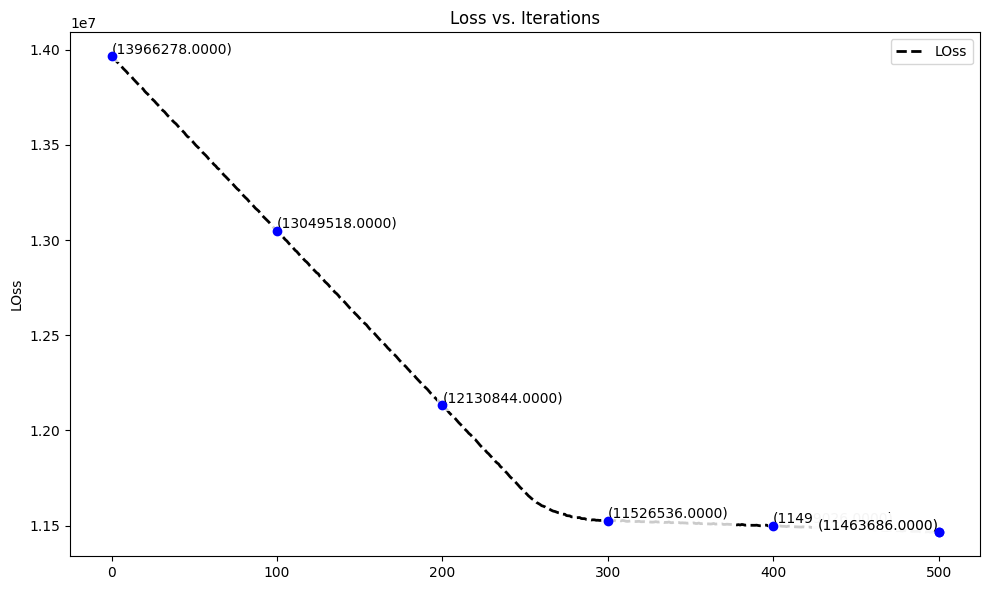

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'black'
ax1.set_ylabel('LOss', color=color)
ax1.plot(range(len(LS_his)), LS_his, label='LOss', color=color, linewidth=2, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Mark specific points
marker_points = [
    0,  # First point
    *range(100, len(LS_his), 100),  # Every 200th point
    len(LS_his)-1  # Last point
]

for point in marker_points:
    ax1.scatter(point, LS_his[point], color='blue', zorder=5)
    ax1.text(point, LS_his[point], 
             f'({LS_his[point]:.4f})',
             ha='right' if point == len(LS_his)-1 else 'left',
             va='bottom',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')
plt.title('Loss vs. Iterations')
plt.tight_layout()
plt.savefig('LS_history.png', dpi=150, bbox_inches='tight')
plt.show()